In [1]:
!pip install xgboost
!pip install shap
!pip install imbalanced-learn

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report
)

from imblearn.over_sampling import SMOTE

import pickle

In [3]:
df = pd.read_csv(
    "/content/Telco_Customer_Churn_Dataset  (1).csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df['TotalCharges'].fillna(
    df['TotalCharges'].median(),
    inplace=True
)

df.drop_duplicates(inplace=True)

df.drop(
    "customerID",
    axis=1,
    inplace=True
)

/tmp/ipykernel_1212/856139595.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(


In [5]:
df['LTV'] = (
    df['MonthlyCharges']
    *
    df['tenure']
)

In [6]:
df['Avg_Revenue'] = (
    df['TotalCharges']
    /
    (df['tenure'] + 1)
)

In [7]:
seg_data = df[
    [
        'tenure',
        'MonthlyCharges',
        'TotalCharges'
    ]
]

In [8]:
scaler_seg = StandardScaler()

seg_scaled = scaler_seg.fit_transform(
    seg_data
)

In [9]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df['Segment'] = kmeans.fit_predict(
    seg_scaled
)

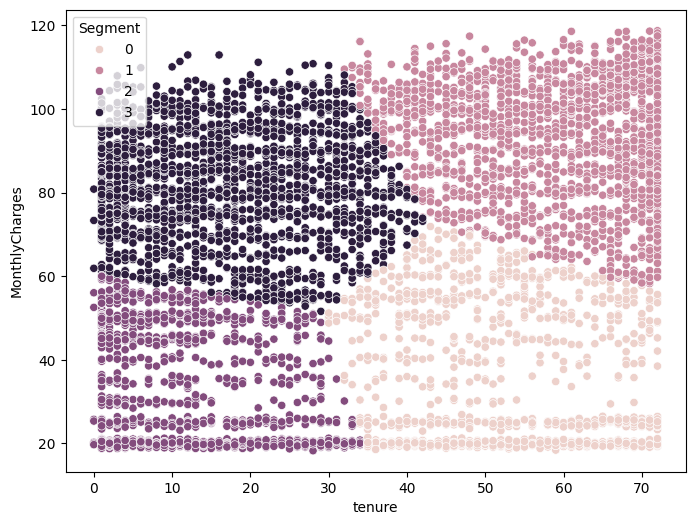

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='tenure',
    y='MonthlyCharges',
    hue='Segment'
)

plt.show()

In [11]:
df['Churn'] = df['Churn'].map(
    {
        'Yes':1,
        'No':0
    }
)

In [12]:
df_model = pd.get_dummies(
    df,
    drop_first=True
)

In [13]:
X = df_model.drop(
    'Churn',
    axis=1
)

y = df_model['Churn']

In [14]:
smote = SMOTE(
    random_state=42
)

X,y = smote.fit_resample(
    X,
    y
)

In [15]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [17]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000)

In [18]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(max_depth=10, n_estimators=300, random_state=42)

In [19]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
)

xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [20]:
models = {
    'Logistic':lr,
    'RandomForest':rf,
    'XGBoost':xgb
}

In [21]:
for name,model in models.items():

    pred = model.predict(X_test)

    auc = roc_auc_score(
        y_test,
        model.predict_proba(X_test)[:,1]
    )

    print(name)
    print("Accuracy:",
          accuracy_score(y_test,pred))
    print("ROC AUC:",
          auc)
    print()

Logistic
Accuracy: 0.8391304347826087
ROC AUC: 0.9247695440552963

RandomForest
Accuracy: 0.8483091787439614
ROC AUC: 0.9241687199879742

XGBoost
Accuracy: 0.857487922705314
ROC AUC: 0.9342856262528839



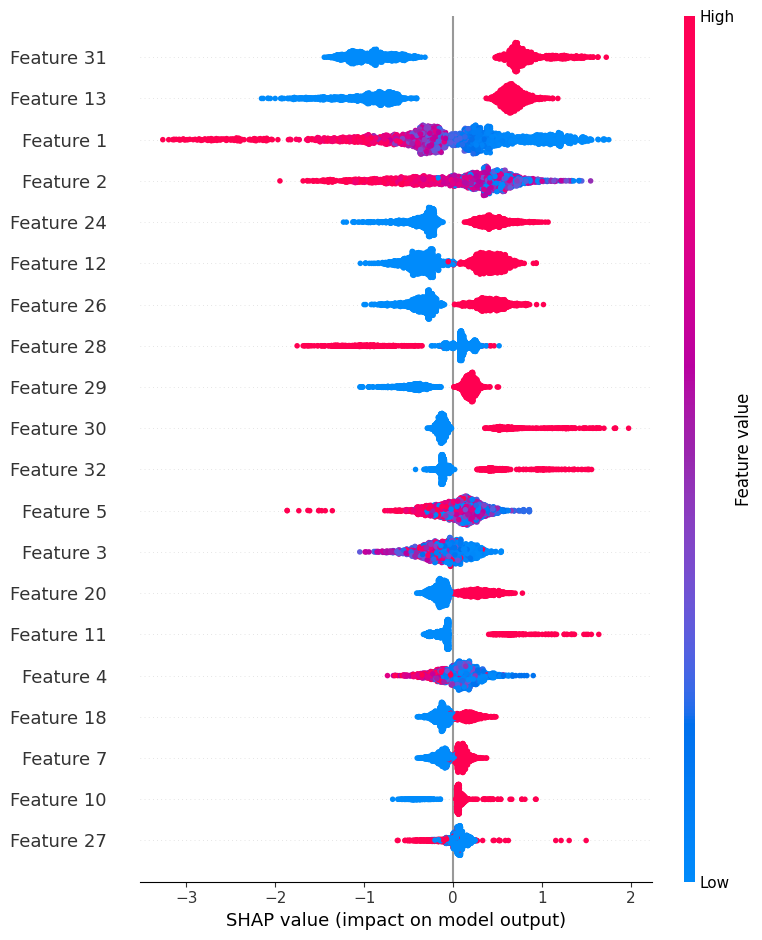

In [22]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(
    X_test
)

shap.summary_plot(
    shap_values,
    X_test
)

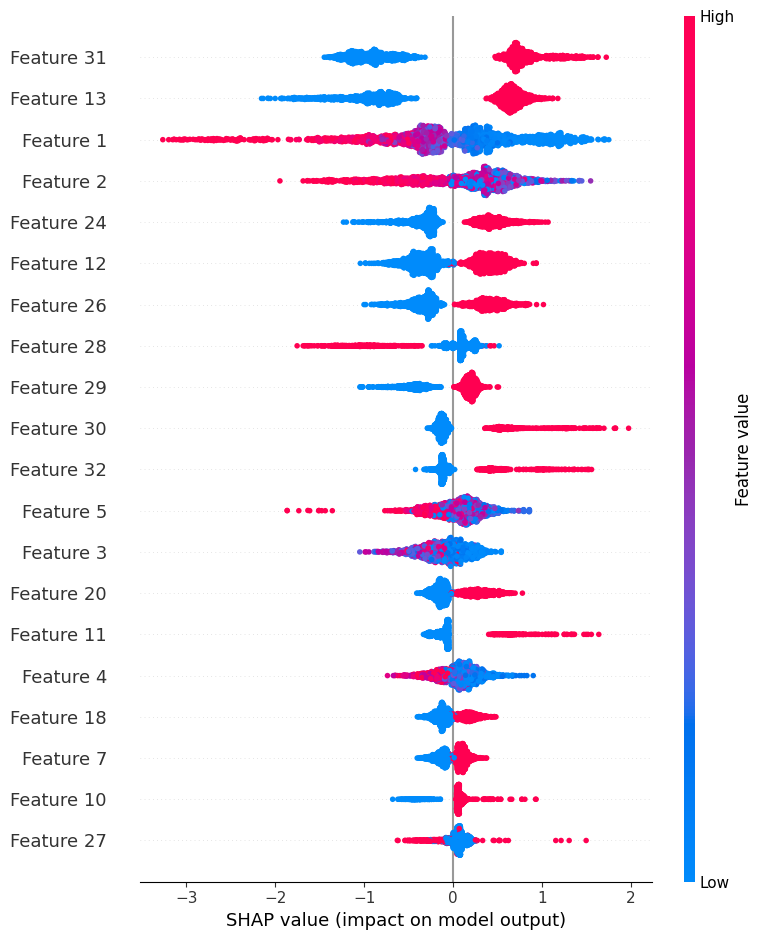

In [23]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(
    X_test
)

shap.summary_plot(
    shap_values,
    X_test
)

In [27]:
X_original = df_model.drop('Churn', axis=1)

X_original_scaled = scaler.transform(X_original)

risk_prob = xgb.predict_proba(X_original_scaled)[:, 1]

risk_df = df.copy()

risk_df['Risk_Probability'] = risk_prob

In [28]:
high_value = risk_df[
    risk_df['LTV']
    >
    risk_df['LTV'].quantile(0.75)
]

In [29]:
high_value_risk = high_value[
    high_value['Risk_Probability']
    >0.7
]

In [30]:
import pickle

In [31]:
import pickle

In [32]:
pickle.dump(
    xgb,
    open(
        'best_model.pkl',
        'wb'
    )
)

In [33]:
pickle.dump(
    scaler,
    open(
        'scaler.pkl',
        'wb'
    )
)

In [34]:
pickle.dump(
    kmeans,
    open(
        'kmeans.pkl',
        'wb'
    )
)

In [35]:
pickle.dump(
    X.columns.tolist(),
    open(
        'feature_columns.pkl',
        'wb'
    )
)

In [36]:
pickle.dump(
    X.columns.tolist(),
    open(
        'feature_columns.pkl',
        'wb'
    )
)